<a href="https://colab.research.google.com/github/amcmdv/Gemini-carnival/blob/experiment-Metabolic-Famine/21122025_Modeling_the_'Metabolic_Famine'.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Modeling the 'The Metabolic Famine'

**The Metabolic Famine (Adaptation)** :

This permutation explores a scenario where energy is low but not zero. In this state, the $Ca^{2+}$ levels stay below the "death" threshold because the connectivity is low, preventing a cascade. You should see the raster plot become very sparse as the network enters a "low-power mode."

**Expected Phenomenon:**

1. Neural Silencing: Cells stop firing to conserve energy;
2. Ca stays moderately high.





---




Upload your spreadsheet (config_ca.csv) or wait for defaults...


/tmp/ipython-input-3594949925.py:95: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  nc = axes[3].scatter(0,0, c=[], cmap='YlOrRd') # dummy for colorbar


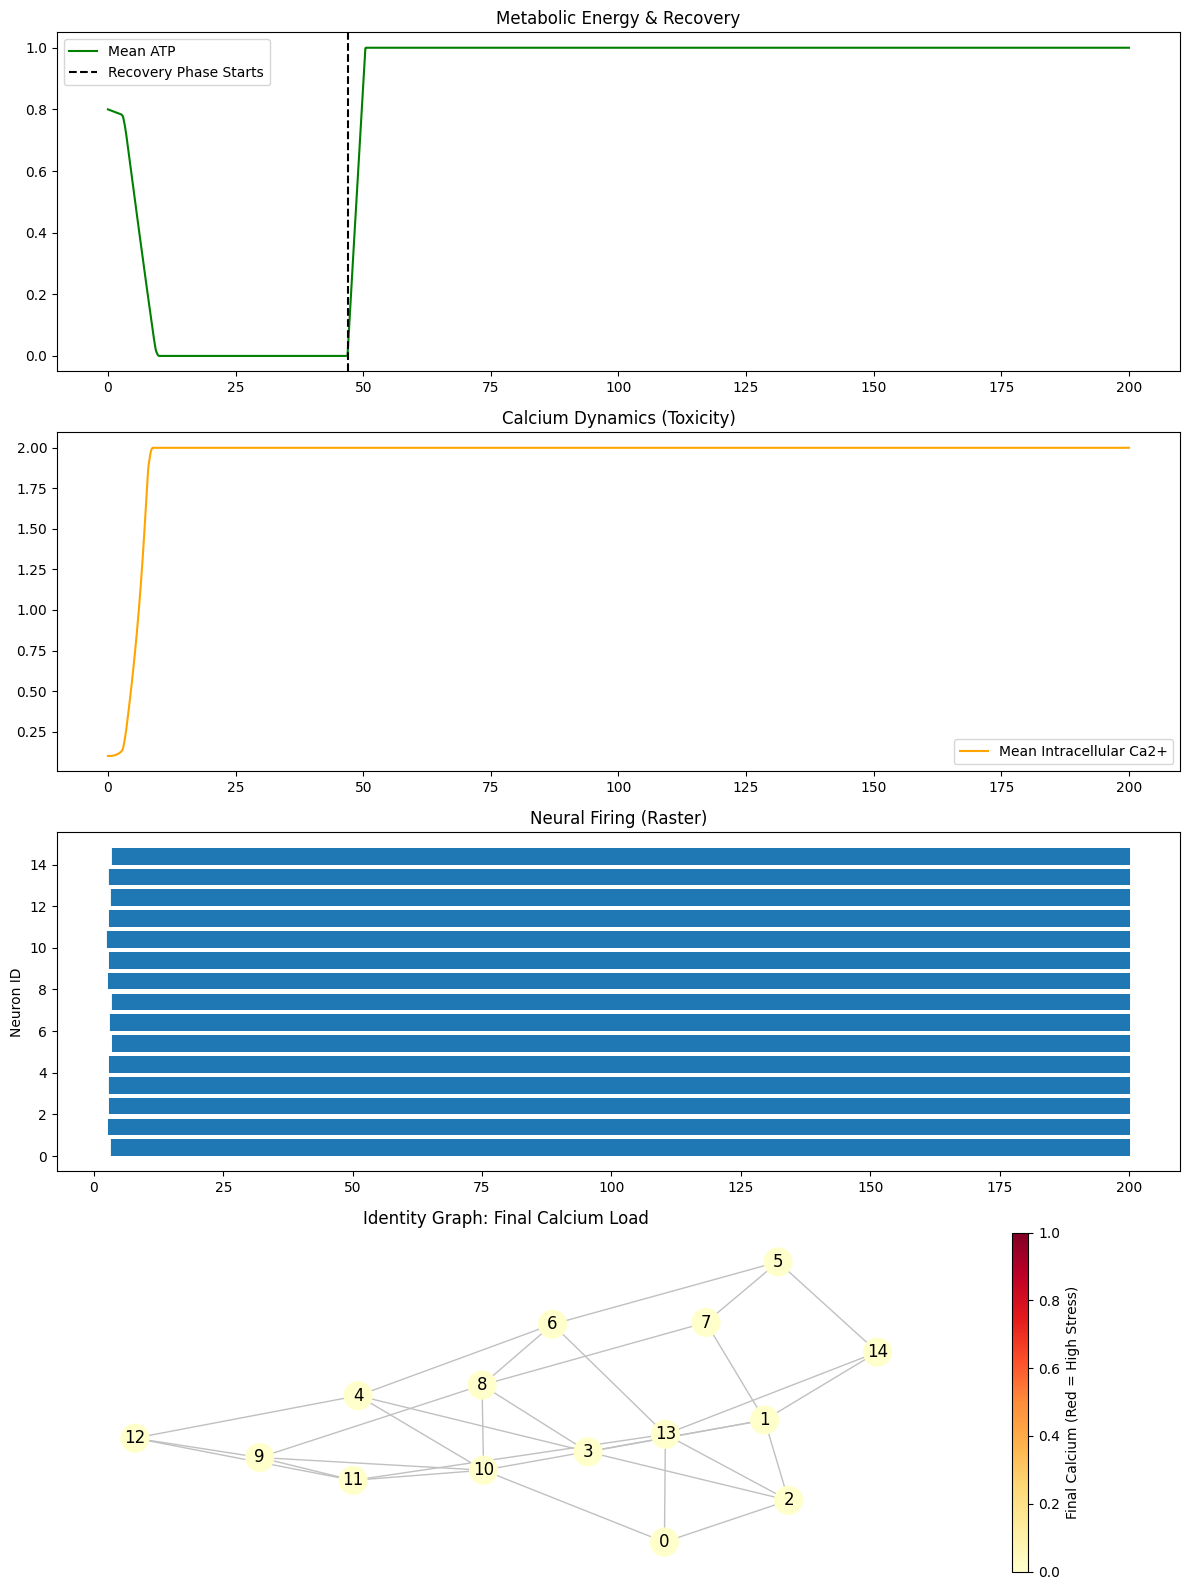

In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict
from google.colab import files
import os

@dataclass
class SimConfig:
    n_cells: int = 15
    connectivity_prob: float = 0.2
    T: float = 200.0
    dt: float = 0.1
    atp_prod_base: float = 0.012  # Low initial state (Stress)
    recovery_time: float = 47.0  # When "Oxygen" returns
    recovery_boost: float = 0.42  # New production rate after recovery
    ca_clearance_rate: float = 0.04
    spike_threshold: float = 0.8

class NeuroCalciumSim:
    def __init__(self, config: SimConfig):
        self.c = config
        self.steps = int(self.c.T / self.c.dt)
        self.rng = np.random.default_rng()
        self.G = nx.watts_strogatz_graph(n=self.c.n_cells, k=4, p=0.3)
        self.adj = nx.to_numpy_array(self.G)

        # State Arrays
        self.v = np.zeros((self.c.n_cells, self.steps))
        self.atp = np.full((self.c.n_cells, self.steps), 0.8)
        self.ca = np.full((self.c.n_cells, self.steps), 0.1) # Intracellular Ca2+
        self.spikes = np.zeros((self.c.n_cells, self.steps))

    def run(self):
        for k in range(1, self.steps):
            t = k * self.c.dt

            # 1. Recovery Logic: Check if we are in the recovery phase
            current_prod = self.c.atp_prod_base if t < self.c.recovery_time else self.c.recovery_boost

            # 2. Pump Efficiency
            pump_eff = self.atp[:, k-1] / (self.atp[:, k-1] + 0.4)

            # 3. Voltage with Calcium Influence
            # High Calcium increases excitability (Feedback loop)
            ca_excitation = 0.4 * self.ca[:, k-1]
            synaptic_in = 0.15 * np.dot(self.adj, self.v[:, k-1])

            dv = (
                synaptic_in +
                ca_excitation +
                0.3 * (1.0 - pump_eff) -
                0.25 * self.v[:, k-1] +
                0.05 * self.rng.normal(size=self.c.n_cells)
            ) * self.c.dt
            self.v[:, k] = self.v[:, k-1] + dv

            # 4. Spike and Calcium Influx
            self.spikes[:, k] = (self.v[:, k] > self.c.spike_threshold).astype(float)

            # Ca increases with spikes and high voltage
            dca = (0.2 * self.spikes[:, k] + 0.05 * self.v[:, k] -
                   self.c.ca_clearance_rate * pump_eff * self.ca[:, k-1]) * self.c.dt
            self.ca[:, k] = np.clip(self.ca[:, k-1] + dca, 0, 2.0)

            # 5. ATP Dynamics
            atp_loss = (0.005 + 0.02 * pump_eff + 0.12 * self.spikes[:, k]) * self.c.dt
            self.atp[:, k] = np.clip(self.atp[:, k-1] + (current_prod * self.c.dt) - atp_loss, 0, 1.0)

    def generate_report(self):
        fig, axes = plt.subplots(4, 1, figsize=(12, 16))
        t_axis = np.linspace(0, self.c.T, self.steps)

        # Plot 1: Mean ATP and Recovery Line
        axes[0].plot(t_axis, np.mean(self.atp, axis=0), color='green', label="Mean ATP")
        axes[0].axvline(x=self.c.recovery_time, color='black', linestyle='--', label="Recovery Phase Starts")
        axes[0].set_title("Metabolic Energy & Recovery")
        axes[0].legend()

        # Plot 2: Calcium Accumulation (Excitotoxicity marker)
        axes[1].plot(t_axis, np.mean(self.ca, axis=0), color='orange', label="Mean Intracellular Ca2+")
        axes[1].set_title("Calcium Dynamics (Toxicity)")
        axes[1].legend()

        # Plot 3: Raster Plot
        for i in range(self.c.n_cells):
            spikes = t_axis[self.spikes[i] > 0]
            axes[2].vlines(spikes, i, i + 0.8)
        axes[2].set_title("Neural Firing (Raster)")
        axes[2].set_ylabel("Neuron ID")

        # Plot 4: Network Health (Final Ca2+ levels)
        pos = nx.spring_layout(self.G)
        nc = axes[3].scatter(0,0, c=[], cmap='YlOrRd') # dummy for colorbar
        nx.draw(self.G, pos, ax=axes[3], node_color=self.ca[:, -1], cmap='YlOrRd',
                with_labels=True, node_size=400, edge_color='silver')
        plt.colorbar(plt.cm.ScalarMappable(cmap='YlOrRd'), ax=axes[3], label="Final Calcium (Red = High Stress)")
        axes[3].set_title("Identity Graph: Final Calcium Load")

        plt.tight_layout()
        plt.show()

# Run Pipeline
def start_pipeline():
    if not os.path.exists('config_ca.csv'):
        pd.DataFrame([asdict(SimConfig())]).to_csv('config_ca.csv', index=False)

    print("Upload your spreadsheet (config_ca.csv) or wait for defaults...")
    uploaded = files.upload()
    config = SimConfig(**pd.read_csv('config_ca.csv').iloc[0].to_dict()) if 'config_ca.csv' in uploaded else SimConfig()

    sim = NeuroCalciumSim(config)
    sim.run()
    sim.generate_report()

start_pipeline()